# Pokémon Catch Difficulty Prediction

In [13]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
print('Inline matplotlib backend enabled')

Inline matplotlib backend enabled


## Project Overview
This project aims to predict the catch difficulty of a Pokémon using its biological, physical, and gameplay-related attributes. The project demonstrates an end-to-end Machine Learning workflow including data cleaning, feature engineering, preprocessing, pipeline construction, model training, and evaluation.

## Problem Statement

In Pokémon games, each Pokémon has a Catch Rate that determines how easy or difficult it is to capture.

The objective of this project is to predict Pokémon Catch Difficulty using various Pokémon characteristics such as type, species, abilities, growth rate, and physical attributes.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pokemon_df=pd.read_csv('pokemonDB_raw_dataset.csv') #loading the dataset

pokemon_df.head()

,Pokemon,Type,Species,Height,Weight,Abilities,EV Yield,Catch Rate,Base Friendship,Base Exp,...,Defense Max,Special Attack Base,Special Attack Min,Special Attack Max,Special Defense Base,Special Defense Min,Special Defense Max,Speed Base,Speed Min,Speed Max
0,Abomasnow,"Grass, Ice",Frost Tree Pokémon,2.2 m (7′03″),135.5 kg (298.7 lbs),"1. Snow Warning, Soundproof (hidden ability)","1 Attack, 1 Sp. Atk","60 (7.8% with PokéBall, full HP)",50 (normal),173,...,273,92,170,311,85,157,295,60,112,240
1,Mega Abomasnow,"Grass, Ice",Frost Tree Pokémon,2.7 m (8′10″),185.0 kg (407.9 lbs),1. Snow Warning,"1 Attack, 1 Sp. Atk","60 (7.8% with PokéBall, full HP)",50 (normal),208,...,339,132,242,399,105,193,339,30,58,174
2,Abra,Psychic,Psi Pokémon,0.9 m (2′11″),19.5 kg (43.0 lbs),"1. Synchronize, 2. Inner Focus, Magic Guard (h...",1 Sp. Atk,"200 (26.1% with PokéBall, full HP)",50 (normal),62,...,141,105,193,339,55,103,229,90,166,306
3,Absol,Dark,Disaster Pokémon,1.2 m (3′11″),47.0 kg (103.6 lbs),"1. Pressure, 2. Super Luck, Justified (hidden ...",2 Attack,"30 (3.9% with PokéBall, full HP)",35 (lower than normal),163,...,240,75,139,273,60,112,240,75,139,273
4,Mega Absol,Dark,Disaster Pokémon,1.2 m (3′11″),49.0 kg (108.0 lbs),1. Magic Bounce,2 Attack,"30 (3.9% with PokéBall, full HP)",35 (lower than normal),198,...,240,115,211,361,60,112,240,115,211,361


In [4]:
# selecting relevant columns

pokemon_df=pokemon_df[['Pokemon', 'Type', 'Species', 'Height', 'Weight', 'Abilities','Catch Rate', 'Base Friendship', 'Base Exp', 'Growth Rate', 'Gender']] 

pokemon_df['Height']=pokemon_df['Height'].str.extract(r'(\d+\.?\d*)')[0].astype('float32') # removing the 'm' from the height column and converting it to float
pokemon_df['Weight']=pokemon_df['Weight'].str.extract(r'(\d+\.?\d*)')[0].astype('float32').round(2) 
# removing the 'kg' from the weight column and converting it to float

pokemon_df=pokemon_df.rename(columns={'Height':'Height (m)', 'Weight':'Weight (kg)'}) # renaming the columns

pokemon_df['Catch Rate']=pokemon_df['Catch Rate'].str.extract(r'(\d+)')[0].astype('float32') 
pokemon_df['Base Friendship']=pokemon_df['Base Friendship'].str.extract(r'(\d+)')[0].astype('float32')

pokemon_df['Abilities']=(pokemon_df['Abilities']
.str.replace(r'\d+\.\s*','',regex=True)
.str.replace(r'\(hidden ability\)','',regex=True) # removing the numbers from the abilities column
)


pokemon_df['Abilities']=pokemon_df['Abilities'].apply(lambda x: ','.join([i.strip()for i in x.split(',')]))

pokemon_df['Male_%']=pokemon_df['Gender'].str.extract(r'(\d+\.?\d*)%\s*male')[0].astype('float32') # extracting the percentage of male

pokemon_df['Female_%']=pokemon_df['Gender'].str.extract(r'(\d+\.?\d*)%\s*female')[0].astype('float32') # extracting the percentage of female

pokemon_df=pokemon_df.rename(columns={'Pokemon':'pokemon', 'Type':'type', 'Species':'species', 'Height (m)': 'height_(m)', 'Weight (kg)':'weight_(kg)', 'Abilities':'abilities',
       'Catch Rate':'catch_rate', 'Base Friendship':'base_friendship', 'Base Exp':'base_exp', 'Growth Rate':'growth_rate', 'Gender':'gender',
       'Male_%':'male_%', 'Female_%':'female_%'})

pokemon_df['base_exp']=pd.to_numeric(pokemon_df['base_exp'], errors='coerce').astype('float32') # converting the base_exp column to numeric and then to float

pokemon_df[['male_%','female_%']]=pokemon_df[['male_%','female_%']].fillna(0) # filling the null values

# filling the null values in the base_friendship column with the median value of the column

pokemon_df['base_friendship']=pokemon_df['base_friendship'].fillna(pokemon_df['base_friendship'].median())

pokemon_df['base_exp']=pokemon_df['base_exp'].fillna(pokemon_df['base_exp'].median()) # filling the missing values in the 'base_exp' column with the median value of the column

pokemon_df.dropna(subset=['catch_rate'],inplace=True) # dropping the null values in the catch_rate column

pokemon_df=pokemon_df.drop(columns='gender') # dropping the gender column

In [5]:
# Creating new features to the dataset

pokemon_df['catch_difficulty'] = (
    pokemon_df['catch_rate'].max()
    - pokemon_df['catch_rate']
).round(2) # creating a new column 'catch_difficulty' --> Higher the value harder to catch the pokemon

pokemon_df['dominant_gender'] = np.where(
    pokemon_df['male_%'] > pokemon_df['female_%'],
    'Male',
    np.where(
        pokemon_df['female_%'] > pokemon_df['male_%'],
        'Female',
        'Balanced'
    )
) # creating a dominant gender between them rather than having two separate columns


pokemon_df.drop(columns=['catch_rate','male_%','female_%'], inplace= True) # dropping the original columns as they are no longer needed

In [6]:
pokemon_df.head()

,pokemon,type,species,height_(m),weight_(kg),abilities,base_friendship,base_exp,growth_rate,catch_difficulty,dominant_gender
0,Abomasnow,"Grass, Ice",Frost Tree Pokémon,2.2,135.5,"Snow Warning,Soundproof",50.0,173.0,Slow,195.0,Balanced
1,Mega Abomasnow,"Grass, Ice",Frost Tree Pokémon,2.7,185.0,Snow Warning,50.0,208.0,Slow,195.0,Balanced
2,Abra,Psychic,Psi Pokémon,0.9,19.5,"Synchronize,Inner Focus,Magic Guard",50.0,62.0,Medium Slow,55.0,Male
3,Absol,Dark,Disaster Pokémon,1.2,47.0,"Pressure,Super Luck,Justified",35.0,163.0,Medium Slow,225.0,Balanced
4,Mega Absol,Dark,Disaster Pokémon,1.2,49.0,Magic Bounce,35.0,198.0,Medium Slow,225.0,Balanced


In [7]:
pokemon_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1214 entries, 0 to 1214
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   pokemon           1214 non-null   object 
 1   type              1214 non-null   object 
 2   species           1214 non-null   object 
 3   height_(m)        1214 non-null   float32
 4   weight_(kg)       1214 non-null   float32
 5   abilities         1214 non-null   object 
 6   base_friendship   1214 non-null   float32
 7   base_exp          1214 non-null   float32
 8   growth_rate       1214 non-null   object 
 9   catch_difficulty  1214 non-null   float32
 10  dominant_gender   1214 non-null   object 
dtypes: float32(5), object(6)
memory usage: 90.1+ KB


## Exploratory Data Analysis (EDA)

#### Univariate Analysis

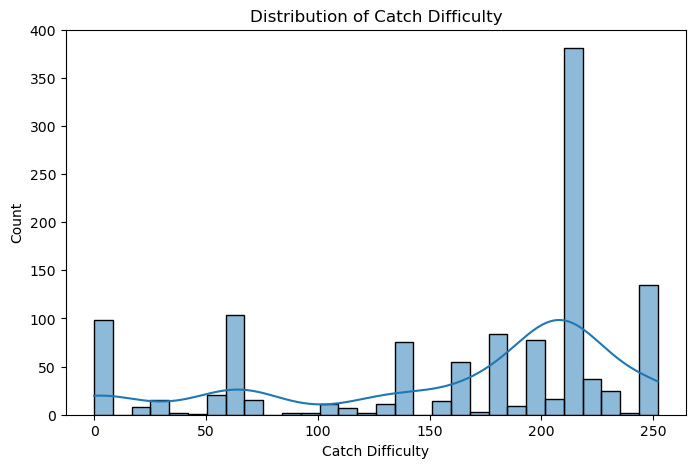

In [17]:
# plot distribution of the numerical column

plt.figure(figsize=(8,5))
sns.histplot(pokemon_df['catch_difficulty'], bins=30,kde=True)

plt.title('Distribution of Catch Difficulty')
plt.xlabel('Catch Difficulty')
plt.ylabel('Count')

plt.show()

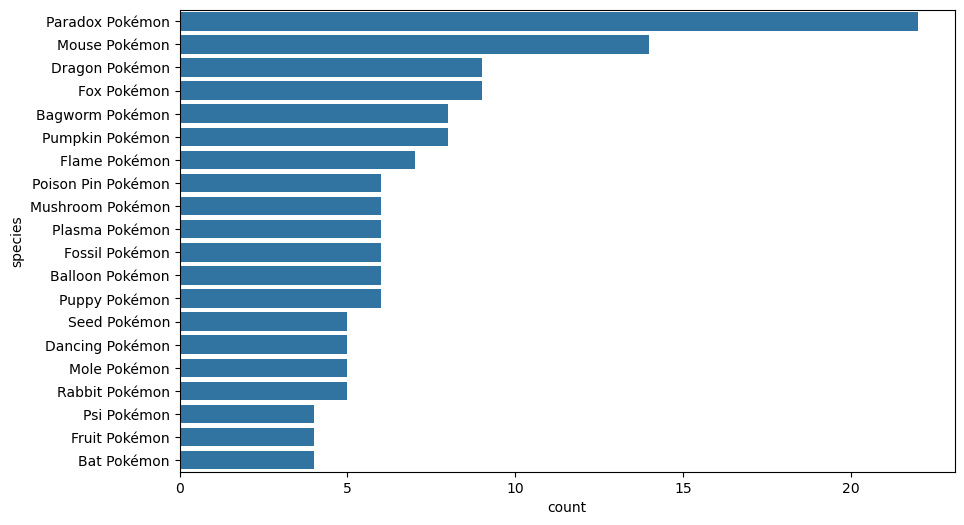

In [18]:
# count plot for categorical variables

plt.figure(figsize=(10,6))

top_species=pokemon_df['species'].value_counts().head(20) # distribution of the type column
sns.countplot(data=pokemon_df,y='species', order=top_species.index) # distribution of the type column
plt.show()


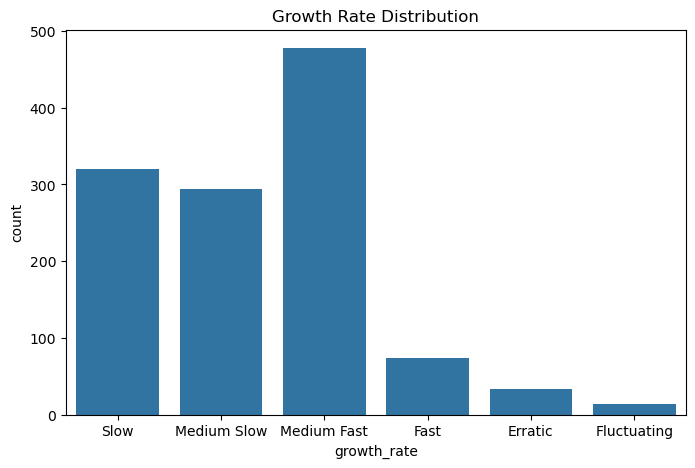

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(data=pokemon_df, x='growth_rate')

plt.title('Growth Rate Distribution')


plt.show()

#### Bivariate Analysis

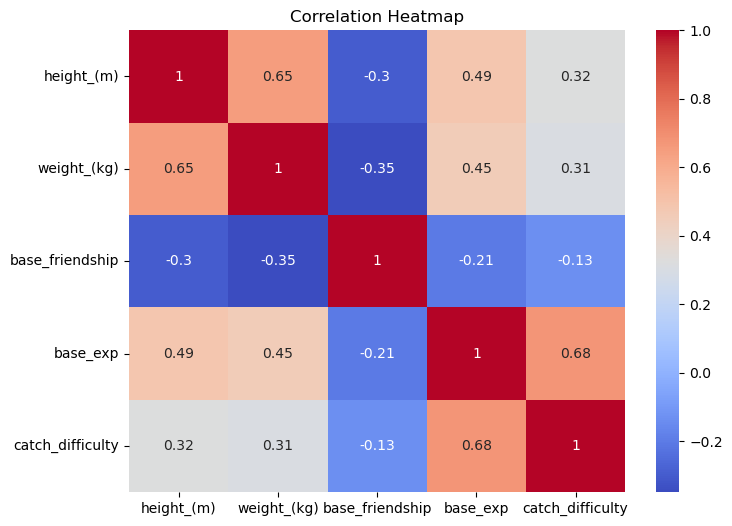

In [22]:
# correlation heatmap

plt.figure(figsize=(8,6))

sns.heatmap(
    pokemon_df.select_dtypes(include='number').corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')

plt.show()

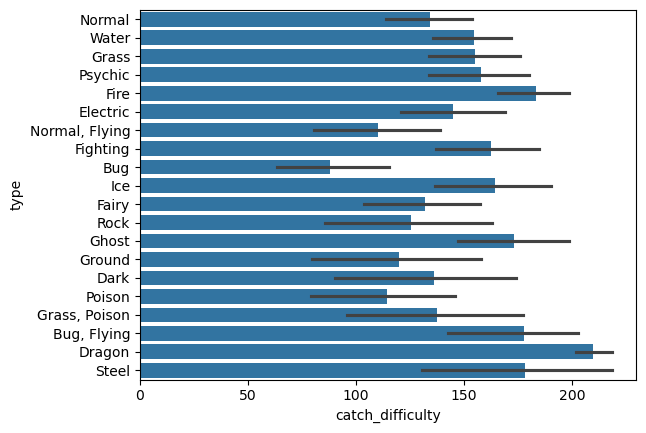

In [28]:
# categorical vs numerical

cat= pokemon_df['type'].value_counts().head(20) # distribution of the type column
sns.barplot(data=pokemon_df,y='type',x='catch_difficulty',order=cat.index) # bar plot to see the distribution of the catch_difficulty for each type
plt.show()

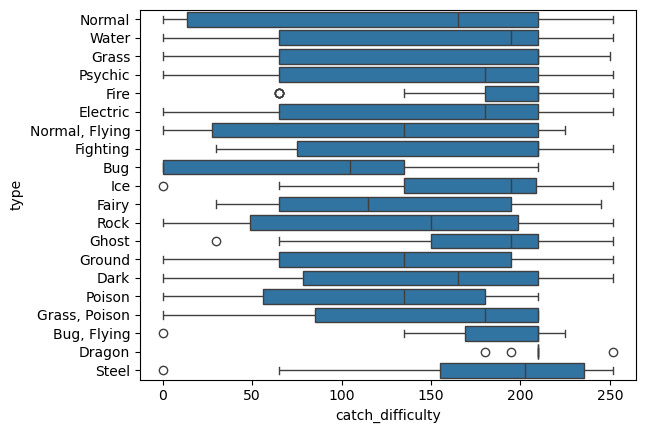

In [29]:
# Box plot

cat= pokemon_df['type'].value_counts().head(20) # distribution of the type column
sns.boxplot(data=pokemon_df,y='type',x='catch_difficulty',order=cat.index) # box plot to see the distribution of the catch_difficulty for each type
plt.show()

In [30]:
pokemon_df.to_csv('cleaned_pokemon_dataset.csv', index=False) # saving the cleaned data to a csv file

In [24]:
##Feature Encoding & Feature Scaling

categorical_cols=pokemon_df.select_dtypes(include='object').columns # selecting the categorical columns

numerical_cols=[
    'height_(m)',
    'weight_(kg)',
    'base_friendship',
    'base_exp'
]
 # selecting the numerical columns , excluding the target variable
 
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

ct=ColumnTransformer(transformers=[('cat', OneHotEncoder(handle_unknown='ignore'),categorical_cols),('num',StandardScaler(),numerical_cols)]) # creating a column transformer to encode the categorical columns and scale the numerical columns

## seperating the features and the target variable

Y=pokemon_df['catch_difficulty'] # target variable
X=pokemon_df.drop(columns='catch_difficulty') # features

# Building Ml Pipelines and Training the Model

from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

pipeline=Pipeline(steps=[
    ('preprocessor',ct),
    ('model',RandomForestRegressor(n_estimators=100, random_state=42))
]) # creating a pipeline to preprocess the data and fit the model


X_train, X_test, Y_train, Y_test=train_test_split(X,Y,test_size=0.2, random_state=42) # splitting the data into training and testing sets

pipeline.fit(X_train, Y_train) # fitting the pipeline on the training data

Y_pred=pipeline.predict(X_test) # making predictions on the test data



In [25]:
# Evaluating the model

from sklearn.metrics import *
mae=mean_absolute_error(Y_test, Y_pred)
mse=mean_squared_error(Y_test, Y_pred)
rmse=np.sqrt(mse)
r2=r2_score(Y_test, Y_pred)

print(f"MAE  : {mae:.2f}")
print(f"MSE  : {mse:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.4f}")

MAE  : 24.33
MSE  : 1529.30
RMSE : 39.11
R²   : 0.7453


In [26]:
## Comparison of the actual vs Predicted values for the Random Forest Regressor model

comparison = pd.DataFrame({
    'Actual': Y_test.values,
    'Predicted': Y_pred
})

print(comparison.tail(10))

     Actual  Predicted
233   125.0      15.00
234   210.0     218.78
235   135.0     148.26
236    20.0      38.00
237    55.0       5.65
238   210.0     204.90
239     0.0       2.60
240   195.0     209.21
241   180.0     183.60
242   210.0     216.30


In [32]:
# Saving the model using joblib

import joblib

joblib.dump(pipeline, "github_pokemon_AIML/models/pokemon_catch_difficulty_model.pkl")

['github_pokemon_AIML/models/pokemon_catch_difficulty_model.pkl']

In [39]:
import pandas as pd

# Get feature names after preprocessing
feature_names = pipeline.named_steps[
    'preprocessor'
].get_feature_names_out()

# Get importance scores
importances = pipeline.named_steps[
    'model'
].feature_importances_

# Create DataFrame
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

# Sort descending
importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

importance_df.head(10)

,Feature,Importance
2424,num__base_exp,0.585500
2420,cat__dominant_gender_Male,0.077573
2417,cat__growth_rate_Slow,0.040605
2422,num__weight_(kg),0.035675
2421,num__height_(m),0.016350
1728,cat__species_Tera Pokémon,0.014791
591,cat__pokemon_Necrozma,0.009040
1165,cat__type_Water,0.007846
2423,num__base_friendship,0.007049
2416,cat__growth_rate_Medium Slow,0.005742


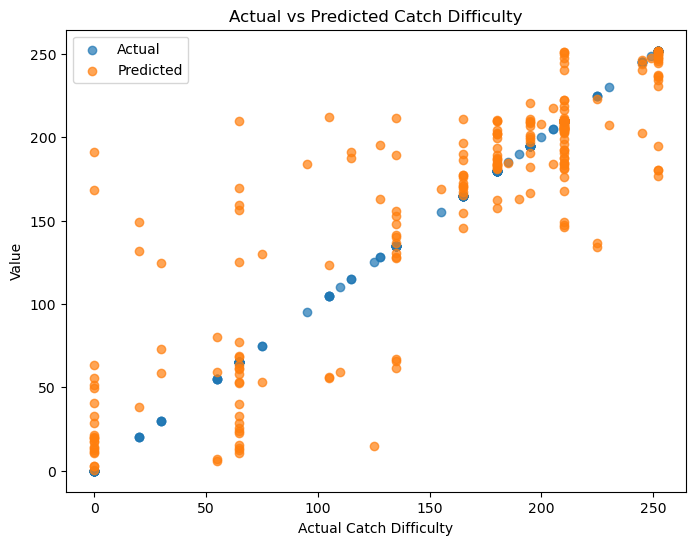

In [30]:
plt.figure(figsize=(8,6))

plt.scatter(
    Y_test,
    Y_test,
    label='Actual',
    alpha=0.7
)

plt.scatter(
    Y_test,
    Y_pred,
    label='Predicted',
    alpha=0.7
)

plt.xlabel("Actual Catch Difficulty")
plt.ylabel("Value")
plt.title("Actual vs Predicted Catch Difficulty")
plt.legend()

plt.show()

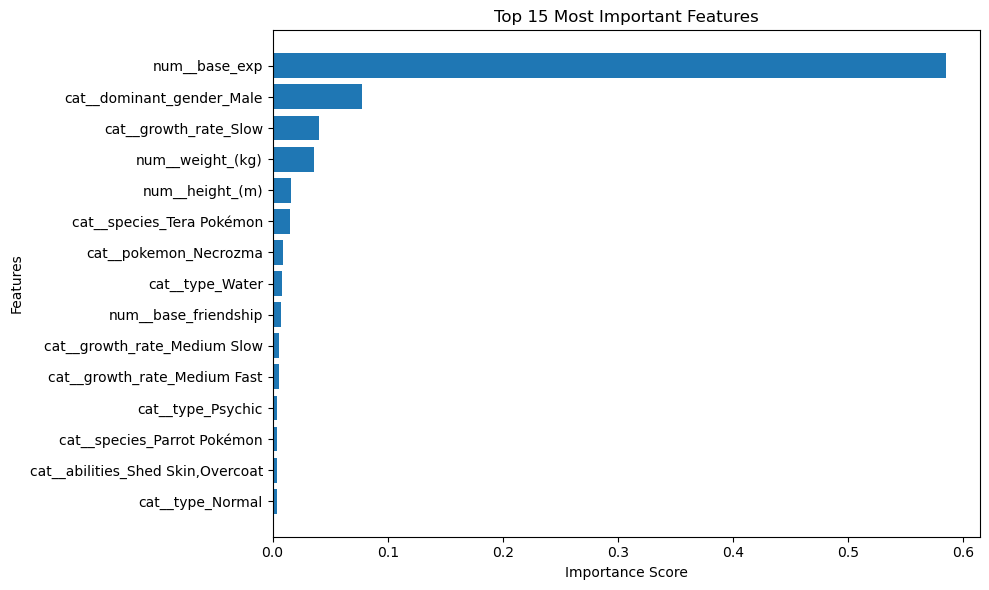

In [40]:
# Top 15 features
top15 = importance_df.head(15)

# Plot
plt.figure(figsize=(10,6))
plt.barh(top15['Feature'], top15['Importance'])

plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.title('Top 15 Most Important Features')

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()